# Mark PCR duplicates

This notebook profile the threshold for marking PCR duplicates.

In [1]:
import os, random, edlib
import multiprocessing as mp
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyBioInfo.IO.File import BamFile
from pyBioInfo.Utils import BundleBuilder

## 1. Random UMI edit distance (barplot)

In [2]:
cells = [
    "20220719_K562_1.C01.K562_s4U_50uM_15min",
    "20220719_K562_1.C02.K562_s4U_50uM_15min",
    "20220719_K562_1.C03.K562_s4U_50uM_15min",
    "20220719_K562_1.C04.K562_s4U_50uM_15min",
    "20220719_K562_1.C05.K562_s4U_50uM_15min",
    "20220719_K562_1.C06.K562_s4U_50uM_15min",
    "20220719_K562_1.C07.K562_s4U_50uM_15min",
    "20220719_K562_1.C08.K562_s4U_50uM_15min",
    "20220719_K562_1.C09.K562_s4U_50uM_15min",
    "20220719_K562_1.C10.K562_s4U_50uM_15min",
]
print("Cells:", len(cells))

Cells: 10


In [3]:
def stat_random_umi_edit_distance(infile, outfile):
    if os.path.exists(outfile):
        print("%s exists!" % outfile)
        return None

    random.seed(0)
    reads = []
    with BamFile(infile, random=True) as f:
        for bundle in BundleBuilder(f, keep=True):
            reads.append(random.sample(bundle.data, 1)[0])   
    umis = [read.segment.get_tag("UM") for read in reads]
    
    eds = []
    for i in range(len(umis) - 1):
        for j in range(i + 1, len(umis)):
            umi1, umi2 = umis[i], umis[j]
            if len(umi1) > len(umi2):
                umi1, umi2 = umi2, umi1
            eds.append(edlib.align(umi1, umi2, mode="HW")["editDistance"])

    m = pd.DataFrame([item for item in sorted(Counter(eds).items())])
    m.columns = ["ED", "Count"]
    m.to_csv(outfile, index=False)
            
pool = mp.Pool(10)
for cell in cells:
    path1 = "../../../1_NanoNASCseq/results/3_mapping/5_mark_duplicate/%s/%s.bam" % (cell.split(".")[0], cell)
    path2 = "results/random_umi_edit_distance/%s.csv" % cell
    pool.apply_async(stat_random_umi_edit_distance, (path1, path2))
pool.close()
pool.join()

In [20]:
max_ed = 8
array = []
for cell in cells:
    counter = defaultdict(int)
    d = pd.read_csv("results/random_umi_edit_distance/%s.csv" % cell)
    for ed, count in d.values:
        counter[min(ed, max_ed)] += count
    array.append(counter)
m = pd.DataFrame(array, index=pd.Index(cells, name="Cell"))

m = m.divide(m.sum(axis=1), axis=0) * 100
m = pd.DataFrame({
    "Mean": m.mean(),
    "Std": m.std(),
    "Size": m.shape[0],
})
m.index = ["0", "1", "2", "3", "4", "5", "6", "7", "ge8"]
m.index.name = "ED"
m.to_csv("results/random_umi_edit_distance.stats.csv")
m

,Mean,Std,Size
ED,,,
0,0.000036,0.000026,10
1,0.000942,0.000052,10
2,0.030391,0.000703,10
3,0.503783,0.005580,10
4,4.428047,0.039114,10
5,19.824247,0.126696,10
6,39.071032,0.116180,10
7,28.223008,0.127771,10
ge8,7.918513,0.140879,10


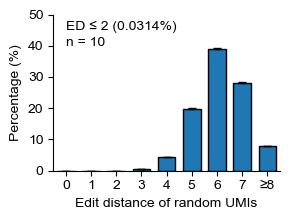

In [36]:
# Plot
m = pd.read_csv("results/random_umi_edit_distance.stats.csv", index_col=0)
xs = np.arange(m.shape[0])
plt.figure(figsize=(3, 2.3))
plt.bar(xs, m["Mean"], yerr=m["Std"], edgecolor="black", width=0.7, color="C0", error_kw={"capsize": 3})
plt.text(0, 45, "ED ≤ 2 (%.4f%%)" % sum(m["Mean"].values[:3]))
plt.text(0, 40, "n = %d" % m["Size"].values[0])
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, "≥8"])
plt.xlabel("Edit distance of random UMIs")
plt.ylabel("Percentage (%)")
plt.xlim(min(xs) - 0.5, max(xs) + 0.5)
plt.ylim(0, 50)
plt.yticks([0, 10, 20, 30, 40, 50])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/random_umi_edit_distance.bar.pdf")
plt.show()
plt.close()

## 2. Reads per UMI (barplot)

In [65]:
d = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv", index_col=0)
d = d[(d["ActD"].isna()) & (d["UMIs"] >= 5000) & (d["Time"] == 3)]
d1 = d[(d["CellLine"] == "K562") & (d["s4U"] == 0)]
d2 = d[(d["CellLine"] == "K562") & (d["s4U"] == 50)]
d3 = d[(d["CellLine"] == "mESC") & (d["s4U"] == 0)]
d4 = d[(d["CellLine"] == "mESC") & (d["s4U"] == 400)]
print(len(d1), len(d2), len(d3), len(d4), sep="\t")

190	179	64	112


In [106]:
def stat_umi_size(infiles, outfile):
    if os.path.exists(outfile):
        print("%s exists!" % outfile)
        # return None
        
    max_size = 10
    array = []
    for infile in infiles:
        counter = defaultdict(int)
        for k, v in sorted(Counter(pd.read_csv(infile, sep="\t", header=0)["AllSize"]).items()):
            counter[min(k, max_size)] += v
        array.append(counter)
    m = pd.DataFrame(array)
    m.columns = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "ge10"]
    m.to_csv(outfile)    

names = [
    "K562.s4U_0uM_3h", 
    "K562.s4U_50uM_3h", 
    "mESC.s4U_0uM_3h", 
    "mESC.s4U_400uM_3h", 
]

for name, d in zip(names, [d1, d2, d3, d4]):
    infiles = ["../../../1_NanoNASCseq/results/3_mapping/5_mark_duplicate/%s/%s.tsv" % (cell.split(".")[0], cell) for cell in d.index]
    outfile = "results/umi_size/%s.csv" % name
    stat_umi_size(infiles, outfile)

results/umi_size/K562.s4U_0uM_3h.csv exists!
results/umi_size/K562.s4U_50uM_3h.csv exists!
results/umi_size/mESC.s4U_0uM_3h.csv exists!
results/umi_size/mESC.s4U_400uM_3h.csv exists!


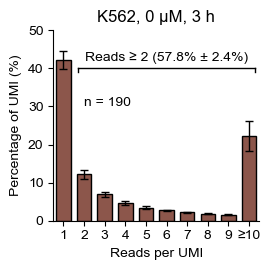

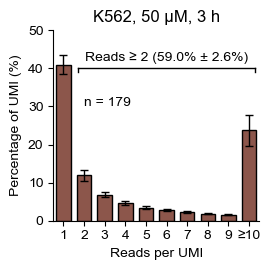

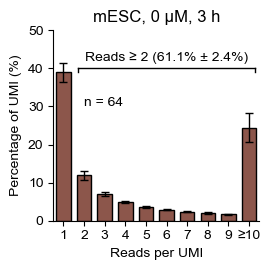

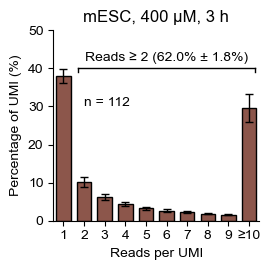

In [139]:
titles = [
    "K562, 0 μM, 3 h",
    "K562, 50 μM, 3 h",
    "mESC, 0 μM, 3 h",
    "mESC, 400 μM, 3 h",
]
for name, title in zip(names, titles):
    m = pd.read_csv("results/umi_size/%s.csv" % name, index_col=0)
    m = m.divide(m.sum(axis=1), axis=0)*100
    xs = np.arange(1, 1 + m.shape[1])
    ys = m.mean().values
    yerr = m.std().values
    
    plt.figure(figsize=(2.8, 2.8))
    plt.title(title)
    plt.bar(xs, ys, yerr=yerr, color="C5", edgecolor="black", width=0.7,
            error_kw={"capsize": 3, "capthick": 1, "lw": 1})
    plt.text(2, 30, "n = %d" % len(m))
    
    if True:
        vs = m[m.columns[m.columns != "1"]].sum(axis=1)
        y = 40
        lw = 1
        plt.text(6, y + 2, "Reads ≥ 2 (%.1f%% ± %.1f%%)" % (np.mean(vs), np.std(vs)), ha="center")
        plt.plot([2 - 0.3, 10 + 0.3], [y, y], lw=lw, color="black")
        plt.plot([2 - 0.3, 2 - 0.3], [y, y - 1], lw=lw, color="black")
        plt.plot([10 + 0.3, 10 + 0.3], [y, y - 1], lw=lw, color="black")
            
    plt.xlim(0.5, 10.5)
    plt.ylim(0, 50)
    plt.xticks(xs, [1, 2, 3, 4, 5, 6, 7, 8, 9, "≥10"])
    plt.xlabel("Reads per UMI")
    plt.ylabel("Percentage of UMI (%)")
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig("figures/umi_size.bar.%s.pdf" % name)
    plt.show()
    plt.close()
    # break

## 3. Number of UMI (violinplot)

In [61]:
d = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv")
d = d[(d["Time"] == 3) & (d["ActD"].isna())]
d1 = d[(d["CellLine"] == "K562") & (d["s4U"] == 0)]
d2 = d[(d["CellLine"] == "K562") & (d["s4U"] == 50)]
d3 = d[(d["CellLine"] == "mESC") & (d["s4U"] == 0)]
d4 = d[(d["CellLine"] == "mESC") & (d["s4U"] == 400)]
print(len(d1), len(d2), len(d3), len(d4), sep="\t") 

196	188	64	121


In [50]:
rows = []
i = 0
for d in [d1, d2, d3, d4]:
    for v in d["UMIs"]:
        rows.append([i, v])
    i += 1
for d in [d1, d2, d3, d4]:
    for v in d["mrUMIs"]:
        rows.append([i, v])
    i += 1
m = pd.DataFrame(rows, columns=["Type", "UMIs"])
m.to_csv("results/umi_number.stats.csv", index=False)

m["Name"] = m["Type"].map({
    0: "K562.s4U_0uM_3h.UMIs",
    1: "K562.s4U_50uM_3h.UMIs",
    2: "mESC.s4U_0uM_3h.UMIs",
    3: "mESC.s4U_400uM_3h.UMIs",
    4: "K562.s4U_0uM_3h.mrUMIs",
    5: "K562.s4U_50uM_3h.mrUMIs",
    6: "mESC.s4U_0uM_3h.mrUMIs",
    7: "mESC.s4U_400uM_3h.mrUMIs",
})

print("Mean\tMedian\t25%\t75%\tName")
for k, v in sorted(m.groupby(by="Name")):
    vs = list(sorted(v["UMIs"]))
    print(round(np.mean(vs), 1), vs[int(len(vs) * 0.5)], vs[int(len(vs) * 0.25)], vs[int(len(vs) * 0.75)], k, sep="\t")

Mean	Median	25%	75%	Name
15024.6	14978	10702	19557	K562.s4U_0uM_3h.UMIs
8705.3	8586	6050	11480	K562.s4U_0uM_3h.mrUMIs
12878.2	11799	8177	16654	K562.s4U_50uM_3h.UMIs
7598.0	6807	4845	10178	K562.s4U_50uM_3h.mrUMIs
15208.9	14797	11042	19352	mESC.s4U_0uM_3h.UMIs
9311.2	9285	6798	11790	mESC.s4U_0uM_3h.mrUMIs
9786.9	9303	7453	11607	mESC.s4U_400uM_3h.UMIs
6077.1	5767	4494	7374	mESC.s4U_400uM_3h.mrUMIs


In [ ]:
m = pd.read_csv("results/umi_number.stats.csv")

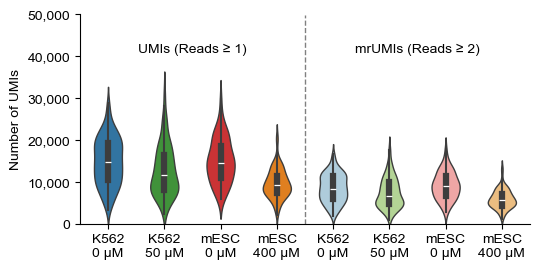

In [59]:
colors = ["C0", "C1", "C2", "C3", "C0", "C1", "C2", "C3"]
cmap = plt.colormaps["Paired"]
colors = [cmap(1), cmap(3), cmap(5), cmap(7), cmap(0), cmap(2), cmap(4), cmap(6)]
xs = np.arange(8)
plt.figure(figsize=(5.5, 2.8))
ret = sns.violinplot(data=m, x="Type", hue="Type", y="UMIs", 
                     density_norm="area", legend=False, width=0.5, linewidth=1, palette=colors)
plt.xlim(-0.5, 7.5)
plt.ylim(0, 50000)
plt.axvline(3.5, lw=1, color="grey", ls="--")
plt.text(1.5, 40000, "UMIs (Reads ≥ 1)", ha="center", va="bottom")
plt.text(5.5, 40000, "mrUMIs (Reads ≥ 2)", ha="center", va="bottom")
plt.xlabel(None)
plt.xticks(xs, [
    "K562\n0 μM", "K562\n50 μM", "mESC\n0 μM", "mESC\n400 μM", 
    "K562\n0 μM", "K562\n50 μM", "mESC\n0 μM", "mESC\n400 μM"])
ys = np.arange(0, 50000 + 1,  10000)
plt.yticks(ys, [format(y, ",") for y in ys])
plt.ylabel("Number of UMIs")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/umi_number.violin.pdf")
plt.show()
plt.close()

## 4. Select reads for IGV visualization (IGV)

Gene: GAPDH

In [47]:
import pysam
bamfile = "../../1_FLAIRseq/results/mapping/mark_duplicate/20220729_K562R1/20220729_K562R1.C02.bam"
outfile = "results/20220729_K562R1.C02.GAPDH2.forIGV.bam"
with pysam.AlignmentFile(bamfile) as f, pysam.AlignmentFile(outfile, "wb", f) as fw:
    data = defaultdict(list)
    for s in f.fetch("chr12", 6534298, 6538480):
        data[s.get_tag("UM")].append(s)
    segments = []
    random.seed(0)
    for k, v in data.items():
        if len(v) > 3:
            segments.extend(random.sample(v, 3))
        else:
            segments.extend(v)
    for s in sorted(segments, key=lambda s: s.reference_start):
        fw.write(s)
! samtools index {outfile}

## 5. Comparison of UMIs

In [53]:
rows = []

In [54]:
d = pd.read_csv("../../1_NanoNASCseq/reports/FLAIRseq_Summary.tsv", sep="\t")
d1 = d[(d["CellLine"] == "K562") & (d["s4U"] == 0) & (d["Time"] == 3) & (d["ActD"].isna())]
for v in d1["UMIs"]:
    rows.append(["NanoNASC-seq (0uM3h)", v])
d2 = d[(d["CellLine"] == "K562") & (d["s4U"] == 50) & (d["Time"] == 3) & (d["ActD"].isna())]
for v in d2["UMIs"]:
    rows.append(["NanoNASC-seq (50uM3h)", v])

In [55]:
d = pd.read_excel("../../A05_SCANseq2/data/Supplementary_Table_S1_Summary_of_sequenced_cells.xlsx")
d = d[d["Cell_Line"] == "K562"]
for v in d["UMI_count"]:
    rows.append(["SCAN-seq2", v])

In [56]:
d = pd.read_csv("../../others/9_PRJEB60799_NASCseq2/data/sourcedata/Figure 1/Fig1f.csv")
d1 = d[d["condition"] == "Untreated"]
for v in d1["total_total"]:
    rows.append(["NASC-seq2 (0uM)", v])
d2 = d[d["condition"] == "Treated"]
for v in d2["total_total"]:
    rows.append(["NASC-seq2 (50uM2h)", v])

In [62]:
m = pd.DataFrame(rows, columns=["Method", "UMIs"])
m["UMIs"] = m["UMIs"] / 1000
m.head()

,Method,UMIs
0,NanoNASC-seq (0uM3h),19.337
1,NanoNASC-seq (0uM3h),15.076
2,NanoNASC-seq (0uM3h),27.957
3,NanoNASC-seq (0uM3h),21.806
4,NanoNASC-seq (0uM3h),11.993


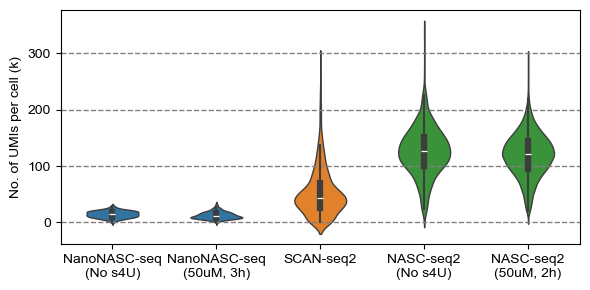

In [74]:
colors = ["C0", "C0", "C1", "C2", "C2"]
plt.figure(figsize=(6, 3))
ret = sns.violinplot(data=m, x="Method", hue="Method", y="UMIs", density_norm="area", legend=False, width=0.5, linewidth=1, palette=colors)
plt.xlabel(None)
plt.xticks([0, 1, 2, 3, 4], ["NanoNASC-seq\n(No s4U)", "NanoNASC-seq\n(50uM, 3h)", "SCAN-seq2", "NASC-seq2\n(No s4U)", "NASC-seq2\n(50uM, 2h)"])
plt.ylabel("No. of UMIs per cell (k)")
plt.grid(axis="y", lw=1, ls="--", color="grey")
plt.tight_layout()
plt.savefig("figures/comparison_of_umis.pdf")